In [ ]:
# ==========================================================
# Enterprise Consumer Complaint Intelligence System
# Notebook 01 : Exploratory Data Analysis
# ==========================================================

# Numerical Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/Customer_project/Consumer_Complaints.csv"
)

In [ ]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 670598
Columns : 18


In [ ]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,07/29/2013,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,NaN,NaN,Wells Fargo & Company,VA,24540,NaN,NaN,Phone,07/30/2013,Closed with explanation,Yes,No,468882
1,07/29/2013,Bank account or service,Checking account,Using a debit or ATM card,NaN,NaN,NaN,Wells Fargo & Company,CA,95992,Older American,NaN,Web,07/31/2013,Closed with explanation,Yes,No,468889
2,07/29/2013,Bank account or service,Checking account,"Account opening, closing, or management",NaN,NaN,NaN,Santander Bank US,NY,10065,NaN,NaN,Fax,07/31/2013,Closed,Yes,No,468879
3,07/29/2013,Bank account or service,Checking account,Deposits and withdrawals,NaN,NaN,NaN,Wells Fargo & Company,GA,30084,NaN,NaN,Web,07/30/2013,Closed with explanation,Yes,No,468949
4,07/29/2013,Mortgage,Conventional fixed mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Franklin Credit Management,CT,06106,NaN,NaN,Web,07/30/2013,Closed with explanation,Yes,No,475823


In [ ]:
df.tail()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
670593,11/16/2016,Credit reporting,NaN,Incorrect information on credit report,Reinserted previously deleted info,NaN,NaN,Equifax,NV,895XX,NaN,NaN,Web,11/16/2016,In progress,Yes,NaN,2211891
670594,10/26/2016,Mortgage,Conventional adjustable mortgage (ARM),"Loan modification,collection,foreclosure",NaN,"We purchased our home in XX/XX/XXXX at the peak of the real estate market in our area. As first time home buyers we were excited but uneducated on the varying types of loans. We qualified and received a 10 year A.R.M. loan. We have diligently made the payment every month on time till XX/XX/XXXX when our rate adjusted and our payment increased {$660.00}. We were aware of and anticipated the rate adjustment but the actual increase was far more than expected or sustainable with our budget. Over the years, we have reached out to several different mortgage brokers for direction. However the outcome was always the same and no one would refinance our loan for the followings reasons ; 1 ) we are self employed 2 ) the loan is not a XXXX or XXXX and 3 ) negative equity. Time and time again the advice was "" just deal with the payment when it adjusts '' or "" sell the house prior to the adjustment ''. \nXX/XX/XXXX we decided to the best option for our circumstances was a loan modification through our lender Citi Mortgage Inc. We contacted Citi and requested a loan modification. We were assigned a 'dedicated Single Point of Contact ' representative to assist with the process. Paper work was requested. Paperwork was returned. More paperwork was requested and returned. Again more paperwork requested and returned. Its been 5 months and we are still waiting for a decision - "" it is still in underwriting ''. \nThe egregious processing delay has caused extreme frustration and caused further financial hardship, hardly the help and hope they ( Citi ) advertise.",Company has responded to the consumer and the CFPB and chooses not to provide a public response,Citibank,UT,847XX,NaN,Consent provided,Web,10/26/2016,Closed with explanation,Yes,Yes,2179768
670595,11/17/2016,Credit reporting,NaN,Incorrect information on credit report,Personal information,NaN,NaN,Equifax,TN,37174,Servicemember,NaN,Web,11/17/2016,Closed with explanation,Yes,Yes,2212094
670596,09/22/2016,Credit card,NaN,Closing/Cancelling account,NaN,"I have had an American Express card for over twenty years and recently received a letter from them stating that Federal Guidelines require a physical address for my account and if I do not provide one within two weeks my account will be closed. Is this correct and legal? I use a US Post Office box for all my bills and have had no problems. I am a XXXX and work and live on XXXX hence no physical address. When I am off for a period of time, I generally short term rent and store my few belongings in a storage unit. I can not be the only one with this lifestyle. Ii know many people who live year round in RVs.",NaN,Amex,FL,322XX,NaN,Consent provided,Web,09/22/2016,Closed with explanation,Yes,NaN,2126003
670597,08/13/2016,Consumer Loan,Installment loan,Managing the loan or lease,NaN,NaN,NaN,BancorpSouth Bank,MS,39301,NaN,Consent not provided,Web,09/07/2016,Closed with explanation,Yes,No,2062419


In [ ]:
df.sample(5, random_state=42)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
171133,06/19/2014,Debt collection,Mortgage,Taking/threatening an illegal action,Seized/Attempted to seize property,NaN,NaN,TD Bank US Holding Company,NJ,07677,"Older American, Servicemember",NaN,Web,06/23/2014,Closed with explanation,Yes,No,901518
220537,09/10/2015,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,NaN,Company believes the complaint is the result of a misunderstanding,ERC,MN,56482,Servicemember,Consent not provided,Web,09/10/2015,Closed with non-monetary relief,Yes,No,1559777
384814,05/23/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen,CA,90005,NaN,NaN,Web,05/24/2013,Closed with explanation,Yes,No,415467
357476,08/27/2015,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Nationstar Mortgage,NY,13209,NaN,NaN,Referral,09/11/2015,Closed with explanation,Yes,No,1540116
180947,10/01/2014,Credit card,NaN,Identity theft / Fraud / Embezzlement,NaN,NaN,NaN,Capital One,MI,48111,NaN,NaN,Web,10/07/2014,Closed with explanation,Yes,No,1053625


In [ ]:
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670598 entries, 0 to 670597
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 670598 non-null  object
 1   Product                       670598 non-null  object
 2   Sub-product                   472396 non-null  object
 3   Issue                         670598 non-null  object
 4   Sub-issue                     269868 non-null  object
 5   Consumer complaint narrative  114704 non-null  object
 6   Company public response       145197 non-null  object
 7   Company                       670598 non-null  object
 8   State                         665293 non-null  object
 9   ZIP code                      665274 non-null  object
 10  Tags                          94730 non-null   object
 11  Consumer consent provided?    208151 non-null  object
 12  Submitted via                 670598 non-null  object
 13 

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date received,670598,1818,08/27/2015,963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,670598,12,Mortgage,210324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-product,472396,47,Other mortgage,81715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue,670598,95,"Loan modification,collection,foreclosure",106455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-issue,269868,68,Account status,32633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer complaint narrative,114704,112690,"I am filing this complaint because Experian has ignored my request to provide me with the documents that their company has on file that was used to verify the accounts I disputed. Being that they have gone past the 30 day mark and can not verify these accounts, under Section 611 ( 5 ) ( A ) of the FCRA - they are required to "" ... promptly delete all information which can not be verified '' that I have disputed. Please resolve this manner as soon as possible. Thank you.",102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company public response,145197,10,Company has responded to the consumer and the CFPB and chooses not to provide a public response,57364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,670598,3933,Bank of America,61720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,665293,62,CA,97640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZIP code,665274,27889,300XX,2147,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Tags,575868,85.87
Consumer complaint narrative,555894,82.90
Company public response,525401,78.35
Consumer consent provided?,462447,68.96
Sub-issue,400730,59.76
Sub-product,198202,29.56
Consumer disputed?,41419,6.18
ZIP code,5324,0.79
State,5305,0.79
Date received,0,0.00


In [ ]:
print("="*50)
print("Duplicate Rows")
print("="*50)

print(df.duplicated().sum())

Duplicate Rows
0


In [ ]:
df.shape

(670598, 18)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Tags,575868
Consumer complaint narrative,555894
Company public response,525401
Consumer consent provided?,462447
Sub-issue,400730
Sub-product,198202
Consumer disputed?,41419
ZIP code,5324
State,5305
Date received,0


In [ ]:
df["Consumer complaint narrative"].head()

,Consumer complaint narrative
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
df["Product"].value_counts()

,count
Product,
Mortgage,210324
Debt collection,124236
Credit reporting,119195
Credit card,79007
Bank account or service,76084
Consumer Loan,26604
Student loan,21651
Payday loan,4786
Money transfers,4720


In [ ]:
df = df.dropna(subset=["Consumer complaint narrative"])

print(df.shape)

(114704, 18)


In [ ]:
print(
    "Duplicate complaints :",
    df["Consumer complaint narrative"].duplicated().sum()
)

Duplicate complaints : 2014


In [ ]:
df = df.drop_duplicates(
    subset=["Consumer complaint narrative"]
)

print(df.shape)

(112690, 18)


In [ ]:
df.reset_index(
    drop=True,
    inplace=True
)

In [ ]:
df.isnull().sum()

,0
Date received,0
Product,0
Sub-product,34540
Issue,0
Sub-issue,57343
Consumer complaint narrative,0
Company public response,56545
Company,0
State,346
ZIP code,351


In [ ]:
df["Product"].value_counts()

,count
Product,
Debt collection,28169
Mortgage,24625
Credit reporting,20995
Credit card,13545
Bank account or service,10397
Consumer Loan,6378
Student loan,4939
Payday loan,1244
Prepaid card,1140


In [ ]:
remove_classes = [
    "Virtual currency",
    "Other financial service"
]

df = df[
    ~df["Product"].isin(remove_classes)
]

print(df["Product"].value_counts())

Product
Debt collection            28169
Mortgage                   24625
Credit reporting           20995
Credit card                13545
Bank account or service    10397
Consumer Loan               6378
Student loan                4939
Payday loan                 1244
Prepaid card                1140
Money transfers             1073
Name: count, dtype: int64


In [ ]:
df["Product"].value_counts()

,count
Product,
Debt collection,28169
Mortgage,24625
Credit reporting,20995
Credit card,13545
Bank account or service,10397
Consumer Loan,6378
Student loan,4939
Payday loan,1244
Prepaid card,1140


In [ ]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/24/2015,Credit card,NaN,Other,NaN,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collectio

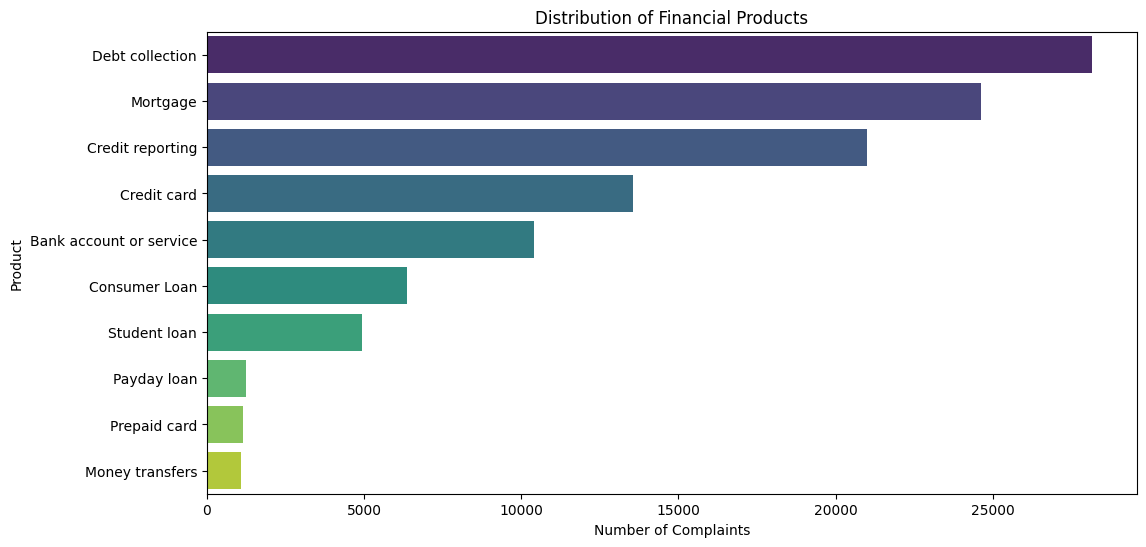

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Product",
    order=df["Product"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Financial Products")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")

plt.show()

In [ ]:
product_percent = round(
    df["Product"].value_counts(normalize=True)*100,
    2
)

product_percent

,proportion
Product,
Debt collection,25.04
Mortgage,21.89
Credit reporting,18.66
Credit card,12.04
Bank account or service,9.24
Consumer Loan,5.67
Student loan,4.39
Payday loan,1.11
Prepaid card,1.01


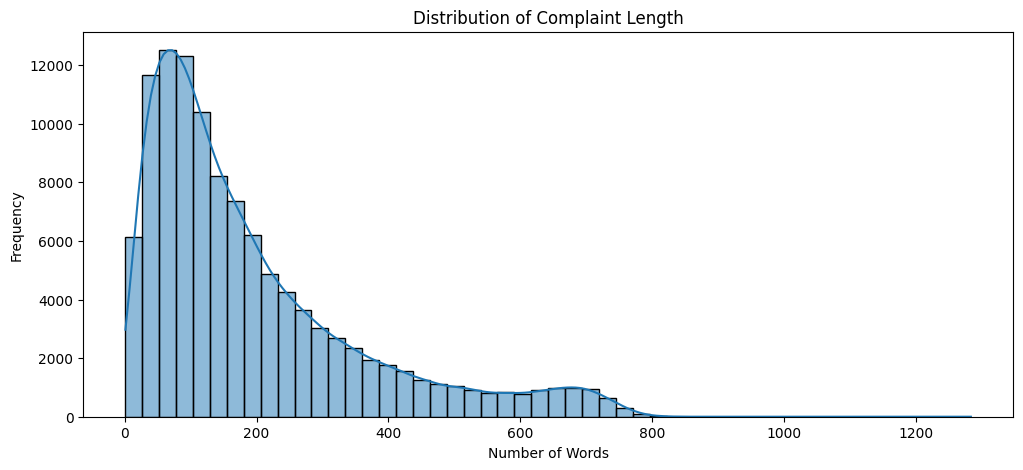

In [ ]:
df["Complaint_Length"] = (
    df["Consumer complaint narrative"]
    .str.split()
    .apply(len)
)

plt.figure(figsize=(12,5))

sns.histplot(
    df["Complaint_Length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Complaint Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

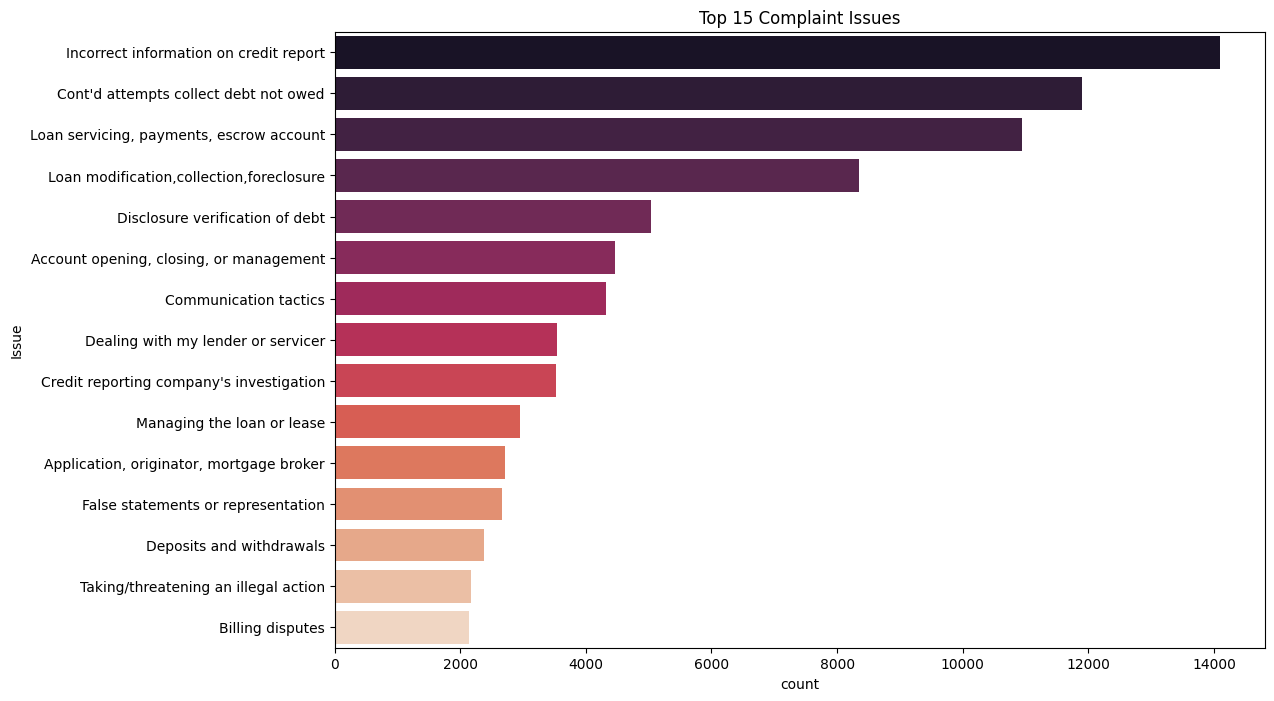

In [ ]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="Issue",
    order=df["Issue"].value_counts().head(15).index,
    palette="rocket"
)

plt.title("Top 15 Complaint Issues")

plt.show()

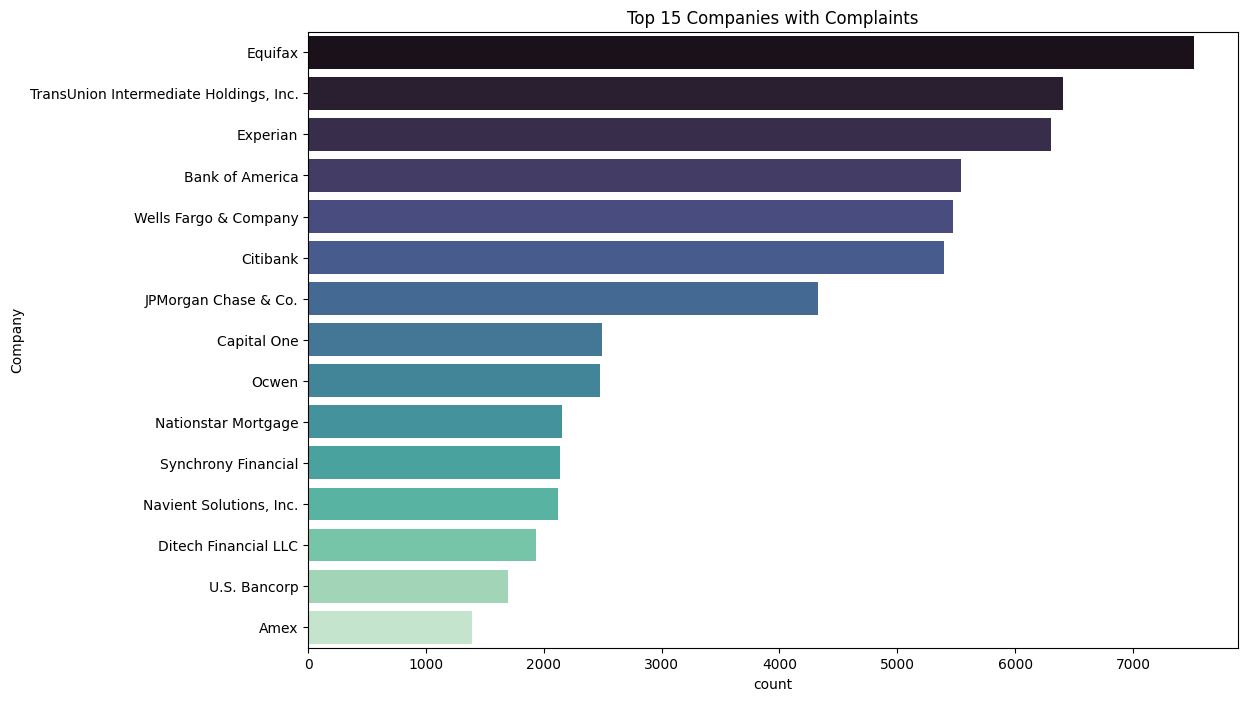

In [ ]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="Company",
    order=df["Company"].value_counts().head(15).index,
    palette="mako"
)

plt.title("Top 15 Companies with Complaints")

plt.show()

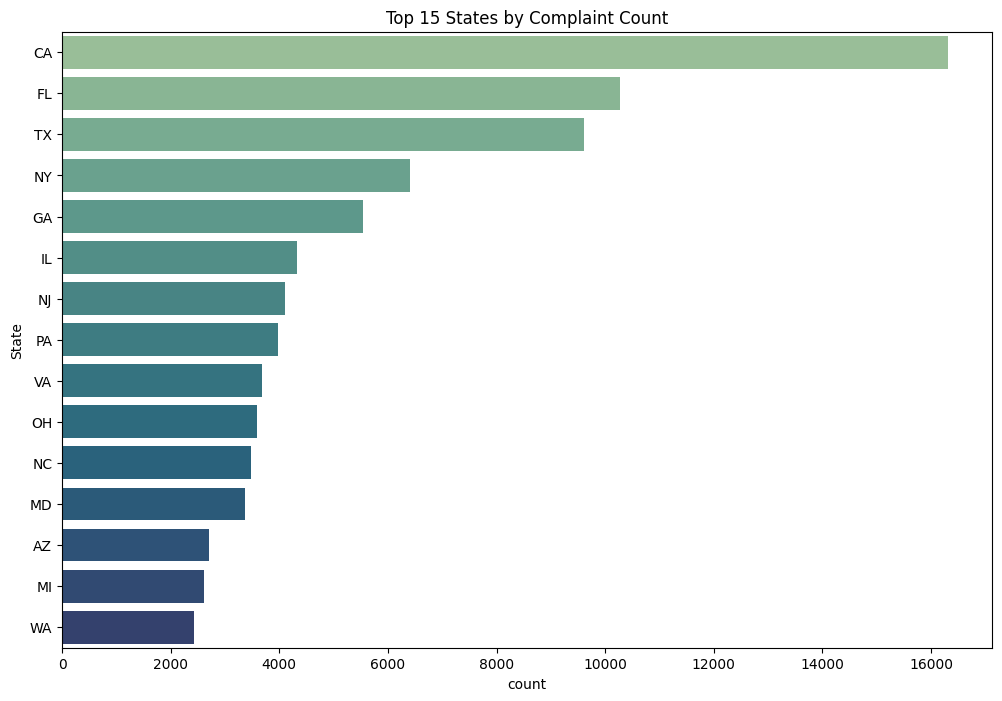

In [ ]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="State",
    order=df["State"].value_counts().head(15).index,
    palette="crest"
)

plt.title("Top 15 States by Complaint Count")

plt.show()

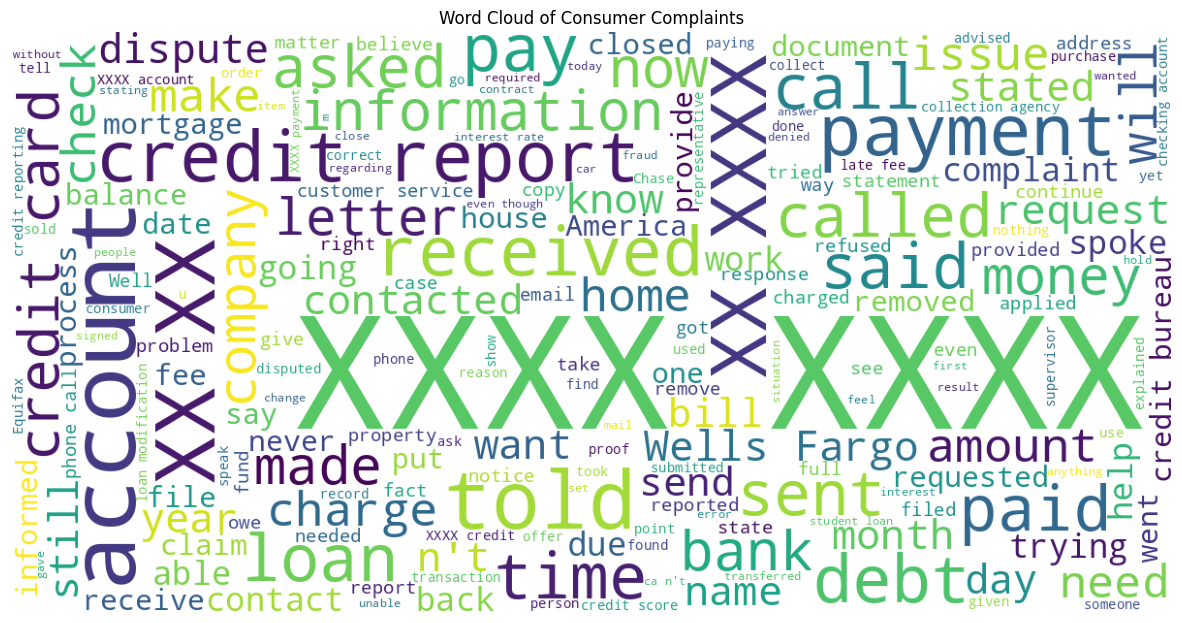

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["Consumer complaint narrative"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Consumer Complaints")
plt.show()

In [ ]:
df_nlp = df[[
    "Consumer complaint narrative",
    "Product"
]].copy()

In [ ]:
df_nlp.head()

,Consumer complaint narrative,Product
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",Credit card
1,I do n't know how they got my cell number. I told them would dea

In [ ]:
df_nlp.rename(columns={
    "Consumer complaint narrative":"Complaint",
    "Product":"Product"
}, inplace=True)

df_nlp.head()

,Complaint,Product
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",Credit card
1,I do n't know how they got my cell number. I told them would deal onlybwith the ori

In [ ]:
df_nlp.isnull().sum()

,0
Complaint,0
Product,0


In [ ]:
df["Product"].value_counts()

,count
Product,
Debt collection,28169
Mortgage,24625
Credit reporting,20995
Credit card,13545
Bank account or service,10397
Consumer Loan,6378
Student loan,4939
Payday loan,1244
Prepaid card,1140


In [ ]:
print("="*50)
print("Dataset Information")
print("="*50)

df_nlp.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 112505 entries, 0 to 112689
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Complaint  112505 non-null  object
 1   Product    112505 non-null  object
dtypes: object(2)
memory usage: 2.6+ MB


In [ ]:
df_nlp["Complaint_Length"] = (
    df_nlp["Complaint"]
    .str.split()
    .apply(len)
)

df_nlp.head()

,Complaint,Product,Complaint_Length
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",Credit card,714
1,I do n't know how they got my cell number. I told them would d

In [ ]:
df_nlp["Complaint_Length"].describe()

,Complaint_Length
count,112505.000000
mean,194.587432
std,168.879864
min,1.000000
25%,73.000000
50%,139.000000
75%,260.000000
max,1284.000000


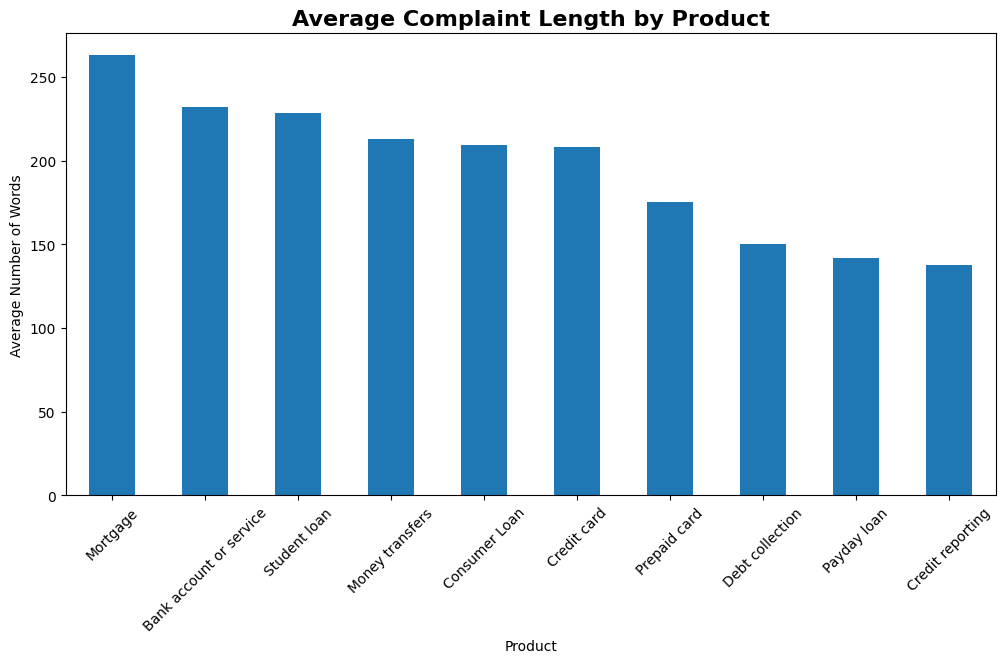

In [ ]:
avg_len = (
    df_nlp
    .groupby("Product")["Complaint_Length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

avg_len.plot(kind="bar")

plt.title("Average Complaint Length by Product",
          fontsize=16,
          fontweight="bold")

plt.ylabel("Average Number of Words")

plt.xticks(rotation=45)

plt.show()

EDA_NLP


In [ ]:
from collections import Counter

all_words = " ".join(df_nlp["Complaint"]).lower().split()

vocab = Counter(all_words)

print("Vocabulary Size :", len(vocab))

Vocabulary Size : 140432


In [ ]:
top_words = pd.DataFrame(
    vocab.most_common(30),
    columns=["Word","Frequency"]
)

top_words

,Word,Frequency
0,the,910994
1,i,815426
2,xxxx,756783
3,to,742729
4,and,590535
5,a,445244
6,my,435827
7,of,344891
8,that,338208
9,was,299785


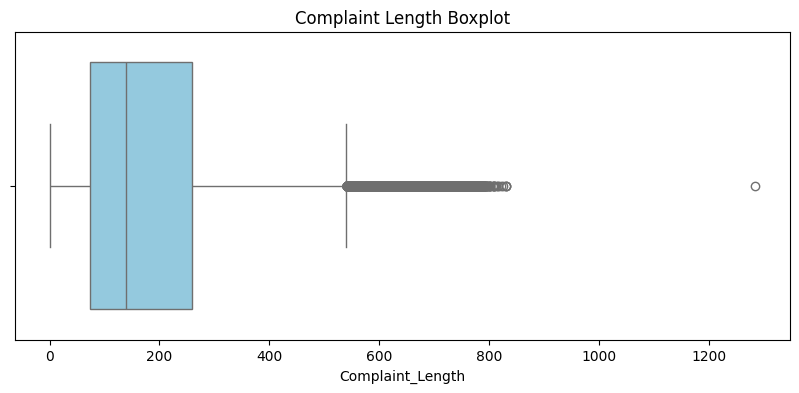

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df_nlp["Complaint_Length"],
    color="skyblue"
)

plt.title("Complaint Length Boxplot")

plt.show()

**preprocessing**


In [ ]:
import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")  # for newer NLTK versions


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [ ]:
print(df_nlp.loc[0, "Complaint"])

Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70

In [ ]:
df = df_nlp

In [ ]:
df.head()

,Complaint,Product,Complaint_Length
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",Credit card,714
1,I do n't know how they got my cell number. I told them would d

In [ ]:
# ==========================================================
# Complete Text Preprocessing Function
# ==========================================================

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Email IDs
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove XXXX
    text = re.sub(r"\bxxxx\b", " ", text)

    # Remove Numbers
    text = re.sub(r"\d+", " ", text)

    # Remove Punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Stopword Removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    text = " ".join(words)

    return text

In [ ]:
df["Processed_Complaint"] = df["Complaint"].apply(preprocess_text)

df.head()

,Complaint,Product,Complaint_Length,Processed_Complaint
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",Credit card,714,received capital one charge card offer appli

In [ ]:
print(
    "Empty Complaints :",
    (df["Processed_Complaint"] == "").sum()
)

Empty Complaints : 2


In [ ]:
df = df[df["Processed_Complaint"] != ""]

In [ ]:
comparison = df[[
    "Complaint",
    "Processed_Complaint",
    "Product"
]]

comparison.head(10)

,Complaint,Processed_Complaint,Product
0,"Received Capital One charge card offer XXXX. Applied, was accepted ( {$500.00} limit ), activated card and used for XXXX presents. Charge card # XXXX. Right after activating card ... Capital One sent me another card with same {$500.00} limit ... never activated ... never used that card. First bill from above card # came due XXXX and minimum payment due was {$15.00}. I sent in {$20.00} via USPMO and sent in before due date. With the XXXX non-activated, non used credit card ... ..they also sent me bill for some yearly fees when never even activated the card. So called them up ... ... .told them did not want the card and sent back to them. Well ... .get my next bill from the card # above ( XXXX ) ... .they did not credit me for the {$20.00} payment and charged me outrageous over the limit fees, late fees, etc ... and now {$70.00} payment due. So, I called up, their rep stated they accidentally applied my {$20.00} payment to wrong account number and would be corrected. So, I sent in a {$70.00} payment via USPMO along with note to make sure account corrected and both payments applied to correct account number ( minimum due and wanted to keep that card and also repair my credit from bankruptcy in XXXX or XXXX. ) So ... XXXX bill came in the mail ... .and once again ... ..they did not apply my payment of {$70.00}, nor the previous payment of {$20.00} ... .which they stated they would correct. They charged me more outrageous over the limit fees, late fees, etc, along with some stupid note about "" spreading yourself too thin. '' I thought wow ... .this is total bs ... ..so I called numerous times, wrote numerous times ... with no success of them correcting my account, when they acknowledged their mistake ( s ) ... ... then they wanted {$120.00} for minimum payment ... .I thought this is totally illegal. Sent my payments in on time and sent in more than minimum to even begin with. Kept calling and writing, with no resolution like they stated. I totally quit paying at that point ... Did not know what else to do at that time. Sometime around end of XXXX started getting threatening phone calls from some collection agency ... ... I mean really threatening. Like about every other day. Well, I ended up extremely ill, in and out of hospitals around that time, doctors, more hospitals, XXXX, XXXX, XXXX ... ..etc ... ..ended up in XXXX and XXXX entire summer, due to XXXX, XXXX ( XXXX at time ) XXXX ... XXXX, XXXX, and more ( Have all the records. ) Anyway ... come XXXX or XXXX, XXXX, XXXX, XXXX put a freeze on my bank account. ( currently XXXX XXXX ... Never knew took me to court & did an illegal Judgement. Called Capital One ... they new NOTHING ... Called XXXX etc..asked for verification XXXX XXXX ), etc..of my account, payments, court order, etc. Did receive back some info of my account. It clearly shows that they put my more than minimum payments onto a totally different account ... ..I now have the proof, of their illegal practices regarding Capital One and XXXX, XXXX and XXXX. I also have my stubs from my payments sent to them via USPMO for further proof. Now, just recently I have been calls at my home from unknown number stating to call XXXX stating something to the effect of ( my name ) and "" property at ( my home ) address '' being sent from the clerks office. My Mother, who is owner of this home, has also been getting such calls and days in row ... regarding me and the "" property at ( my home address. ) and clerk of court. Now she is the owner of this home which we rent ... and her property has nothing to do with my Capital One account which they totally illegally screwed me on..along with XXXX, XXXX XXXX XXXX illegal collection practices. So, I did look on website, and the Attorney for XXXX, XXXX, XXXX did do a Judgement renewal previous to us getting these harassing, threatening, illegal calls. Need help here. \n",received capital one charge card offer applied accepted limit activated card 

In [ ]:
empty = (df["Processed_Complaint"].str.strip() == "").sum()

print("Empty Complaints :", empty)

Empty Complaints : 0


In [ ]:
from collections import Counter

words = " ".join(df["Processed_Complaint"]).split()

vocab = Counter(words)

print("Vocabulary Size :", len(vocab))

Vocabulary Size : 76237


In [ ]:
from collections import Counter

word_freq = Counter(
    " ".join(df["Processed_Complaint"]).split()
)

top_words = pd.DataFrame(
    word_freq.most_common(30),
    columns=["Word", "Frequency"]
)

top_words.head()

,Word,Frequency
0,account,151787
1,credit,146107
2,payment,119772
3,loan,97822
4,would,82742


In [ ]:
df.to_csv(
    "/content/drive/MyDrive/Customer_project/final_complaints.csv",
    index=False
)

In [ ]:

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
!pip install xgboost

In [ ]:
results = []

In [ ]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_model(model, model_name):

    # Train
    model.fit(X_train_bow, y_train)

    # Prediction
    y_pred = model.predict(X_test_bow)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    # Save Results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Print Results
    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    return model

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

In [ ]:
print(df.columns)

Index(['Complaint', 'Product', 'Complaint_Length', 'Processed_Complaint'], dtype='object')


In [ ]:
X = df["Processed_Complaint"]

y = df["Product"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(90002,)
(22501,)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

X_train_bow = bow.fit_transform(X_train)

X_test_bow = bow.transform(X_test)

In [ ]:
print(X_train_bow.shape)
print(X_test_bow.shape)

(90002, 66999)
(22501, 66999)


Naive Bayes
Accuracy : 0.8234
Precision: 0.8209
Recall   : 0.8234
F1 Score : 0.8148

Classification Report

                         precision    recall  f1-score   support

Bank account or service       0.76      0.84      0.80      2079
          Consumer Loan       0.75      0.62      0.68      1276
            Credit card       0.76      0.80      0.78      2709
       Credit reporting       0.79      0.86      0.82      4199
        Debt collection       0.84      0.81      0.83      5633
        Money transfers       0.86      0.26      0.39       215
               Mortgage       0.92      0.95      0.94      4925
            Payday loan       0.45      0.02      0.04       249
           Prepaid card       0.90      0.17      0.28       228
           Student loan       0.81      0.84      0.83       988

               accuracy                           0.82     22501
              macro avg       0.78      0.62      0.64     22501
           weighted avg       0.82      0.82 

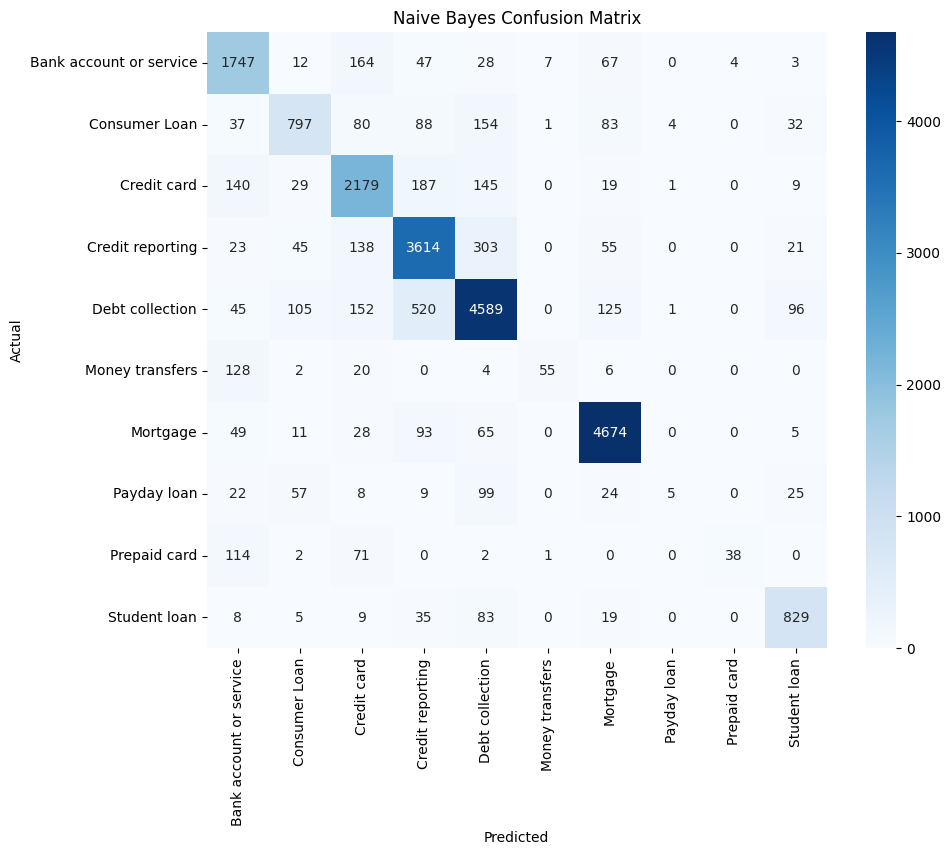

In [ ]:
nb_model = evaluate_model(
    MultinomialNB(),
    "Naive Bayes"
)

Logistic Regression
Accuracy : 0.8302
Precision: 0.8286
Recall   : 0.8302
F1 Score : 0.8286

Classification Report

                         precision    recall  f1-score   support

Bank account or service       0.77      0.77      0.77      2079
          Consumer Loan       0.72      0.60      0.66      1276
            Credit card       0.80      0.77      0.79      2709
       Credit reporting       0.84      0.87      0.86      4199
        Debt collection       0.81      0.86      0.83      5633
        Money transfers       0.64      0.57      0.61       215
               Mortgage       0.93      0.92      0.93      4925
            Payday loan       0.53      0.41      0.46       249
           Prepaid card       0.71      0.65      0.68       228
           Student loan       0.84      0.80      0.82       988

               accuracy                           0.83     22501
              macro avg       0.76      0.72      0.74     22501
           weighted avg       0.83   

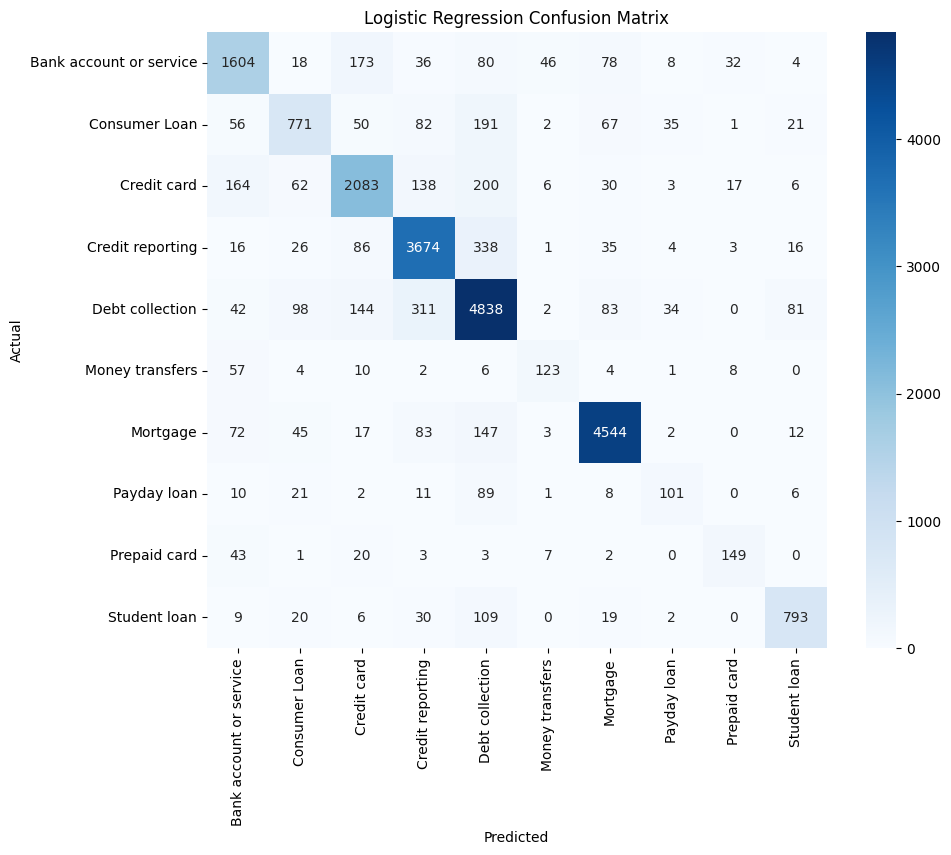

In [ ]:
lr_model = evaluate_model(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Logistic Regression"
)

Linear SVM
Accuracy : 0.8167
Precision: 0.8146
Recall   : 0.8167
F1 Score : 0.8151

Classification Report

                         precision    recall  f1-score   support

Bank account or service       0.76      0.76      0.76      2079
          Consumer Loan       0.68      0.58      0.63      1276
            Credit card       0.78      0.75      0.76      2709
       Credit reporting       0.84      0.86      0.85      4199
        Debt collection       0.80      0.85      0.82      5633
        Money transfers       0.66      0.57      0.61       215
               Mortgage       0.92      0.91      0.92      4925
            Payday loan       0.45      0.39      0.42       249
           Prepaid card       0.65      0.65      0.65       228
           Student loan       0.82      0.79      0.80       988

               accuracy                           0.82     22501
              macro avg       0.74      0.71      0.72     22501
           weighted avg       0.81      0.82  

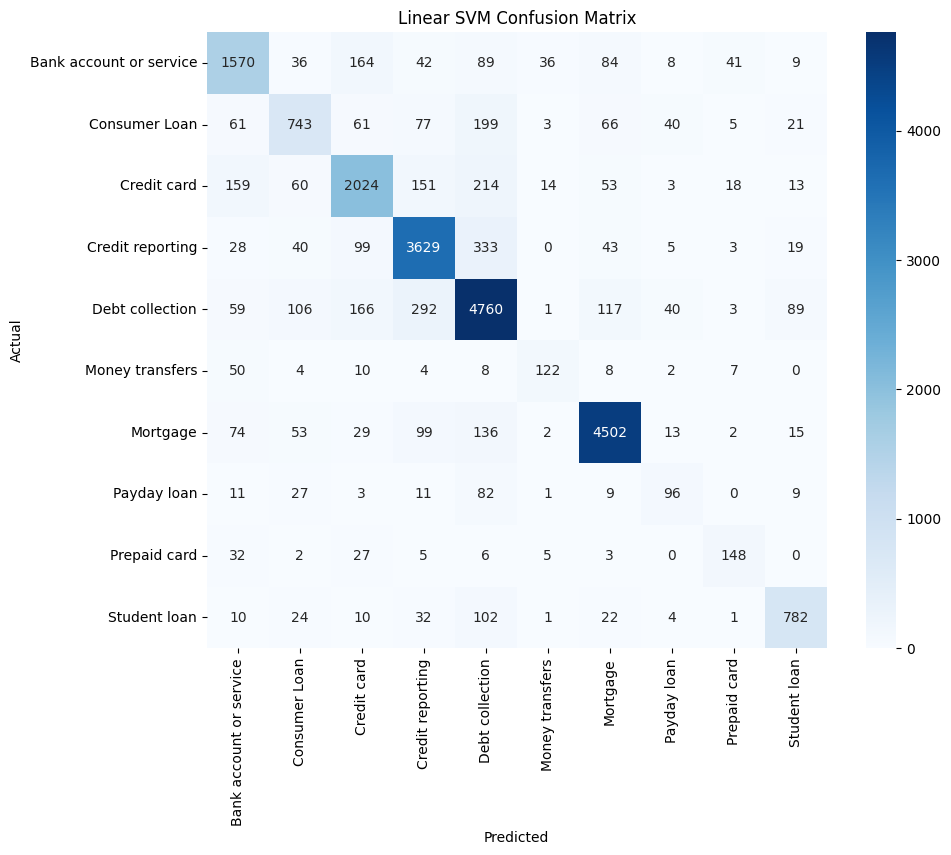

In [ ]:
svm_model = evaluate_model(
    LinearSVC(
        random_state=42
    ),
    "Linear SVM"
)

In [ ]:
# ==========================================================
# Save Everything
# ==========================================================

import os
import joblib
import pandas as pd

# ----------------------------------------------------------
# Create Required Folders
# ----------------------------------------------------------

os.makedirs("/content/drive/MyDrive/Customer_project/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Customer_project/data/splits", exist_ok=True)

# ----------------------------------------------------------
# Save Vectorizer
# ----------------------------------------------------------

joblib.dump(
    bow,
    "/content/drive/MyDrive/Customer_project/models/bow_vectorizer.pkl"
)

# ----------------------------------------------------------
# Save Label Encoder
# ----------------------------------------------------------

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/Customer_project/models/label_encoder.pkl"
)

# ----------------------------------------------------------
# Save Trained Models
# ----------------------------------------------------------

joblib.dump(
    nb_model,
    "/content/drive/MyDrive/Customer_project/models/naive_bayes_bow.pkl"
)

joblib.dump(
    lr_model,
    "/content/drive/MyDrive/Customer_project/models/logistic_regression_bow.pkl"
)

joblib.dump(
    svm_model,
    "/content/drive/MyDrive/Customer_project/models/linear_svm_bow.pkl"
)

['/content/drive/MyDrive/Customer_project/models/linear_svm_bow.pkl']

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.830185,0.828551,0.830185,0.828591
0,Naive Bayes,0.823386,0.820890,0.823386,0.814809
2,Linear SVM,0.816675,0.814641,0.816675,0.815149


In [ ]:
df.to_csv(
    "/content/drive/MyDrive/Customer_project/final_02_comp.csv",
    index=False
)